In [3]:
!pip install open_clip_torch

In [4]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import random
import os
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix)
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
import open_clip
import hashlib


In [5]:
# ========================= KAGGLE VISUALIZATION =========================
from IPython.display import display, Image as IPImage
import matplotlib
matplotlib.use('Agg')   # Must be BEFORE importing pyplot
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec   # (kept in case needed later)

# Helper: save + immediately display in Kaggle
def save_and_display(fig, filename, dpi=200):
    filepath = f"/kaggle/working/{filename}"
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    display(IPImage(filepath))
    print(f"  ✓ Saved and displayed: {filepath}")
    return filepath

In [6]:
# ========================= CONFIG =========================
IMAGE_SIZE = 224
N_WAY = 4
SHOTS = [1, 5, 10]
EPISODES_EVAL = 600

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

CI_ALPHA = 0.05
BOOTSTRAP_N = 1000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print(f"\nFew-Shot Setup | Device: {DEVICE}")
print(f"Episodes: {EPISODES_EVAL} | CI: {int((1-CI_ALPHA)*100)}%")




Few-Shot Setup | Device: cuda
Episodes: 600 | CI: 95%


In [7]:
# ========================= DATASET  =========================

DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "Training")
TEST_DIR  = os.path.join(DATASET_PATH, "Testing")

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
N_WAY = 4


print("Train:", TRAIN_DIR)
print("Test :", TEST_DIR)

Train: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Test : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing


In [8]:
# ========================= LOAD DATA =========================
def load_classwise_split(root):
    classwise = {i: [] for i in range(N_WAY)}

    for i, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(root, cls)
        if os.path.exists(cls_dir):
            classwise[i] = [
                os.path.join(cls_dir, f)
                for f in os.listdir(cls_dir)
            ]

    return classwise


support_pool = load_classwise_split(TRAIN_DIR)
query_pool   = load_classwise_split(TEST_DIR)

print("\nDataset Distribution:")
print("Support:", [len(support_pool[i]) for i in range(N_WAY)])
print("Query  :", [len(query_pool[i]) for i in range(N_WAY)])




Dataset Distribution:
Support: [1400, 1400, 1400, 1400]
Query  : [400, 400, 400, 400]


In [10]:

# ========================= DUPLICATE REMOVAL =========================
def hash_image(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def remove_duplicates(pool):
    cleaned = {}
    removed = 0

    for cls, paths in pool.items():
        seen = set()   
        new_list = []

        for p in paths:
            h = hash_image(p)
            if h not in seen:
                seen.add(h)
                new_list.append(p)
            else:
                removed += 1

        cleaned[cls] = new_list

    return cleaned, removed

print("\n🔧 Removing duplicates...")
support_pool, r1 = remove_duplicates(support_pool)
query_pool, r2   = remove_duplicates(query_pool)

print(f"Removed TRAIN duplicates: {r1}")
print(f"Removed TEST duplicates: {r2}")

# ========================= LEAKAGE CHECK =========================
print("\n================ LEAKAGE CHECK ================")

train_paths = set(sum(support_pool.values(), []))
test_paths  = set(sum(query_pool.values(), []))

overlap = train_paths.intersection(test_paths)

train_hashes = {hash_image(p) for p in train_paths}
test_hashes  = {hash_image(p) for p in test_paths}

dup = train_hashes.intersection(test_hashes)

print("Train-Test overlap:", len(overlap))
print("Exact duplicate images:", len(dup))

assert len(overlap) == 0, "Leakage detected!"
assert len(dup) == 0, "Duplicate leakage detected!"

print("✅ PASS: No leakage detected")



🔧 Removing duplicates...
Removed TRAIN duplicates: 0
Removed TEST duplicates: 0

================ LEAKAGE CHECK ================
Train-Test overlap: 0
Exact duplicate images: 0
✅ PASS: No leakage detected


In [11]:
# ========================= SUMMARY =========================
print("\n================ FINAL DATASET STATS ================")
print("Support samples:", sum(len(v) for v in support_pool.values()))
print("Query samples  :", sum(len(v) for v in query_pool.values()))
print("Classes        :", CLASS_NAMES)


================ FINAL DATASET STATS ================
Support samples: 5429
Query samples  : 1584
Classes        : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [12]:
# ========================= EPISODE CREATION ===========================
def create_episode(k_shot, support_classwise, query_classwise, query_per_class=15):
    support_paths, query_paths = [], []
    support_labels, query_labels = [], []
    for cls_idx in range(N_WAY):
        s_imgs = support_classwise[cls_idx]
        if len(s_imgs) < k_shot:
            s_sel = random.choices(s_imgs, k=k_shot)
        else:
            s_sel = random.sample(s_imgs, k_shot)
        
        q_imgs = query_classwise[cls_idx]
        if len(q_imgs) < query_per_class:
            q_sel = random.choices(q_imgs, k=query_per_class)
        else:
            q_sel = random.sample(q_imgs, query_per_class)
        
        support_paths.extend(s_sel)
        query_paths.extend(q_sel)
        support_labels.extend([cls_idx] * k_shot)
        query_labels.extend([cls_idx] * query_per_class)
    
    return (
        support_paths,
        query_paths,
        torch.tensor(support_labels, dtype=torch.long),
        torch.tensor(query_labels, dtype=torch.long)
    )

In [14]:
# ========================= MODELS =========================
print("Loading models...")
biomed_model, biomed_preprocess = open_clip.create_model_from_pretrained(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
biomed_visual = biomed_model.visual.to(DEVICE)
biomed_visual.eval()

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()
resnet = resnet.to(DEVICE)
resnet.eval()

efficientnet = models.efficientnet_b0(pretrained=True)
efficientnet.classifier = nn.Identity()
efficientnet = efficientnet.to(DEVICE)
efficientnet.eval()

imagenet_preprocess = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

model_configs = {
    "BioMedCLIP": {"encoder": biomed_visual, "preprocess": biomed_preprocess, "dim": 768},
    "ResNet18": {"encoder": resnet, "preprocess": imagenet_preprocess, "dim": 512},
    "EfficientNet-B0": {"encoder": efficientnet, "preprocess": imagenet_preprocess, "dim": 1280}
}
print("✅ Models loaded.\n")

Loading models...
✅ Models loaded.



In [15]:
import shutil

cache_dir = "/kaggle/working/feature_cache_pub"

if os.path.exists(cache_dir):
    print("Clearing old feature cache (dataset changed)...")
    shutil.rmtree(cache_dir)

os.makedirs(cache_dir, exist_ok=True)

Clearing old feature cache (dataset changed)...


In [16]:
# ========================= FEATURE CACHING =========================
cache_dir = "/kaggle/working/feature_cache_pub"
os.makedirs(cache_dir, exist_ok=True)

def extract_features(name, encoder, preprocess, classwise_dict, tag):
    cache_file = os.path.join(cache_dir, f"{name}_{tag}.pt")
    if os.path.exists(cache_file):
        print(f" ✓ Cached [{tag}] {name}")
        return torch.load(cache_file, map_location='cpu')
    all_paths = [p for paths in classwise_dict.values() for p in paths]
    features = {}
    with torch.no_grad():
        for path in tqdm(all_paths, desc=f"{name}[{tag}]"):
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img).unsqueeze(0).to(DEVICE)
                feat = encoder(tensor).squeeze(0).cpu()
                features[path] = feat
            except Exception as e:
                print(f" ⚠ Skipped {path}: {e}")
    torch.save(features, cache_file)
    return features

print("Pre-extracting features...")
support_feats = {}
query_feats = {}
for name, cfg in model_configs.items():
    support_feats[name] = extract_features(name, cfg["encoder"], cfg["preprocess"], support_pool, "train")
    query_feats[name] = extract_features(name, cfg["encoder"], cfg["preprocess"], query_pool, "test")
print("✅ Feature extraction done.\n")

Pre-extracting features...


EfficientNet-B0[test]: 100%|██████████| 1584/1584 [00:19<00:00, 81.05it/s]

✅ Feature extraction done.



In [17]:
# ========================= 95% CONFIDENCE INTERVAL =========================
def bootstrap_ci(acc_list, n=BOOTSTRAP_N, alpha=CI_ALPHA):
    arr = np.array(acc_list)
    samples = np.random.choice(arr, size=(n, len(arr)), replace=True).mean(axis=1)
    lo = np.percentile(samples, 100 * alpha / 2)
    hi = np.percentile(samples, 100 * (1 - alpha / 2))
    return lo, hi

In [18]:
import os

SAVE_DIR = "/kaggle/working/visualization_figure"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f" Saving all outputs to: {SAVE_DIR}")

 Saving all outputs to: /kaggle/working/visualization_figure


In [19]:
# ========================= CONFUSION MATRIX PLOTTER =========================
def plot_confusion_matrix(cm, name, k_shot, mean_acc, std_acc, ci_lo, ci_hi):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor='gray', ax=ax
    )
    ax.set_title(
        f'{name} – {k_shot}-shot\n'
        f'Acc: {mean_acc:.3f} ± {std_acc:.3f}   |   95% CI [{ci_lo:.3f}, {ci_hi:.3f}]',
        fontsize=13, fontweight='bold', pad=14
    )
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
    save_and_display(fig, f"cm_{name}_{k_shot}shot_pub.png")

In [20]:
# ========================= SUMMARY VISUALIZATIONS =========================
def plot_summary_chart(results, shots, model_names):
    n_shots = len(shots)
    n_models = len(model_names)
    x = np.arange(n_models)
    width = 0.25
    fig, axes = plt.subplots(1, n_shots, figsize=(6 * n_shots, 5), sharey=True)
    if n_shots == 1:
        axes = [axes]
    colors = ['#2196F3', '#4CAF50', '#FF9800']

    for ax, k in zip(axes, shots):
        accs = [results[f"{m}_{k}shot"]['mean_acc'] for m in model_names]
        f1s  = [results[f"{m}_{k}shot"]['macro_f1'] for m in model_names]
        cis  = [(results[f"{m}_{k}shot"]['mean_acc'] - results[f"{m}_{k}shot"]['ci_lo'],
                 results[f"{m}_{k}shot"]['ci_hi'] - results[f"{m}_{k}shot"]['mean_acc'])
                for m in model_names]
        ci_arr = np.array(cis).T

        ax.bar(x - width/2, accs, width, label='Accuracy', color=colors, alpha=0.85,
               yerr=ci_arr, capsize=5, error_kw={'elinewidth':1.5})
        ax.bar(x + width/2, f1s, width, label='Macro-F1', color=colors, alpha=0.45, hatch='//')

        for bar in ax.patches[:len(accs)]:   # rough value labels
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_title(f'{k}-Shot', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=15, ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(axis='y', alpha=0.3, linestyle='--')

    fig.suptitle('Few-Shot Brain Tumor Classification\n(Pure Prototypical | Leak-Free | 95% CI)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    save_and_display(fig, "summary_accuracy_f1.png", dpi=200)

def plot_perclass_heatmap(results, shots, model_names):
    row_labels = [f"{m}\n({k}-shot)" for k in shots for m in model_names]
    data = np.array([results[f"{m}_{k}shot"]['per_class_f1'] for k in shots for m in model_names])

    fig, ax = plt.subplots(figsize=(8, max(5, len(row_labels) * 0.55 + 1.5)))
    sns.heatmap(data, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=CLASS_NAMES, yticklabels=row_labels,
                vmin=0, vmax=1, linewidths=0.4, linecolor='white', ax=ax)
    ax.set_title('Per-Class F1 Score (all models × shots)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Model / Shot')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    save_and_display(fig, "perclass_f1_heatmap.png", dpi=200)

def plot_shot_progression(results, shots, model_names):
    fig, ax = plt.subplots(figsize=(8, 5))
    markers = ['o', 's', '^']
    colors = ['#1565C0', '#2E7D32', '#E65100']

    for i, name in enumerate(model_names):
        accs = [results[f"{name}_{k}shot"]['mean_acc'] for k in shots]
        ci_lo = [results[f"{name}_{k}shot"]['ci_lo'] for k in shots]
        ci_hi = [results[f"{name}_{k}shot"]['ci_hi'] for k in shots]
        ax.plot(shots, accs, marker=markers[i], color=colors[i], linewidth=2,
                markersize=8, label=name)
        ax.fill_between(shots, ci_lo, ci_hi, color=colors[i], alpha=0.12)

    ax.set_xlabel('Number of Shots (k)')
    ax.set_ylabel('Mean Accuracy')
    ax.set_title('Accuracy vs. Number of Shots (shaded = 95% CI)', fontsize=13, fontweight='bold')
    ax.set_xticks(shots)
    ax.set_xticklabels([f'{k}-shot' for k in shots])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    save_and_display(fig, "shot_progression.png", dpi=200)

In [21]:
# ========================= run_fewshot =========================
def run_fewshot(k_shot, name):
    print(f"\n{'='*90}")
    print(f"  {k_shot}-SHOT | {name}  (Pure Prototypical | Leak-Free)")
    print(f"{'='*90}")

    s_feats = support_feats[name]
    q_feats = query_feats[name]
    all_true, all_pred = [], []
    episode_preds = []
    accs = []

    for ep in tqdm(range(EPISODES_EVAL), desc=f"{k_shot}-shot {name}"):
        supp_paths, qry_paths, sy, qy = create_episode(
            k_shot, support_pool, query_pool, query_per_class=15
        )
        sy, qy = sy.to(DEVICE), qy.to(DEVICE)

        sf = torch.stack([s_feats[p] for p in supp_paths]).to(DEVICE)
        qf = torch.stack([q_feats[p] for p in qry_paths]).to(DEVICE)

        sf = F.normalize(sf, p=2, dim=-1)
        qf = F.normalize(qf, p=2, dim=-1)

        prototypes = torch.stack([sf[sy == i].mean(dim=0) for i in range(N_WAY)])
        dists = 1 - torch.mm(qf, prototypes.t())
        preds = dists.argmin(dim=1)

        ep_true = qy.cpu().numpy()
        ep_pred = preds.cpu().numpy()

        all_true.extend(ep_true)
        all_pred.extend(ep_pred)
        episode_preds.append(ep_pred)
        accs.append(accuracy_score(ep_true, ep_pred))

    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    ci_lo, ci_hi = bootstrap_ci(accs)

    precision, recall, f1, sup = precision_recall_fscore_support(
        all_true, all_pred, average=None, zero_division=0, labels=list(range(N_WAY))
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        all_true, all_pred, average='macro', zero_division=0
    )
    cm = confusion_matrix(all_true, all_pred)

    print(f"\n  Accuracy  : {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"  95% CI    : [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"  Macro F1  : {macro_f1:.4f} | Precision: {macro_p:.4f} | Recall: {macro_r:.4f}")
    print(f"\n  Per-class metrics:")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"    {cls:12} | P: {precision[i]:.3f} | R: {recall[i]:.3f} | F1: {f1[i]:.3f} | N: {sup[i]}")

    # Plot confusion matrix with inline display
    plot_confusion_matrix(cm, name, k_shot, mean_acc, std_acc, ci_lo, ci_hi)

    return {
        'mean_acc': mean_acc, 'std_acc': std_acc,
        'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'macro_f1': macro_f1, 'macro_p': macro_p, 'macro_r': macro_r,
        'per_class_f1': f1,
        'all_true': all_true, 'all_pred': all_pred,
        'episode_preds': episode_preds
    }


##########################################################################################
FEW-SHOT EXPERIMENTS (600 Episodes)
##########################################################################################


  1-SHOT | BioMedCLIP  (Pure Prototypical | Leak-Free)


1-shot BioMedCLIP: 100%|██████████| 600/600 [00:01<00:00, 596.03it/s]



  Accuracy  : 0.5855 ± 0.0974
  95% CI    : [0.5777, 0.5931]
  Macro F1  : 0.5871 | Precision: 0.5909 | Recall: 0.5855

  Per-class metrics:
    glioma       | P: 0.444 | R: 0.453 | F1: 0.449 | N: 9000
    meningioma   | P: 0.465 | R: 0.432 | F1: 0.448 | N: 9000
    notumor      | P: 0.888 | R: 0.816 | F1: 0.851 | N: 9000
    pituitary    | P: 0.566 | R: 0.641 | F1: 0.601 | N: 9000


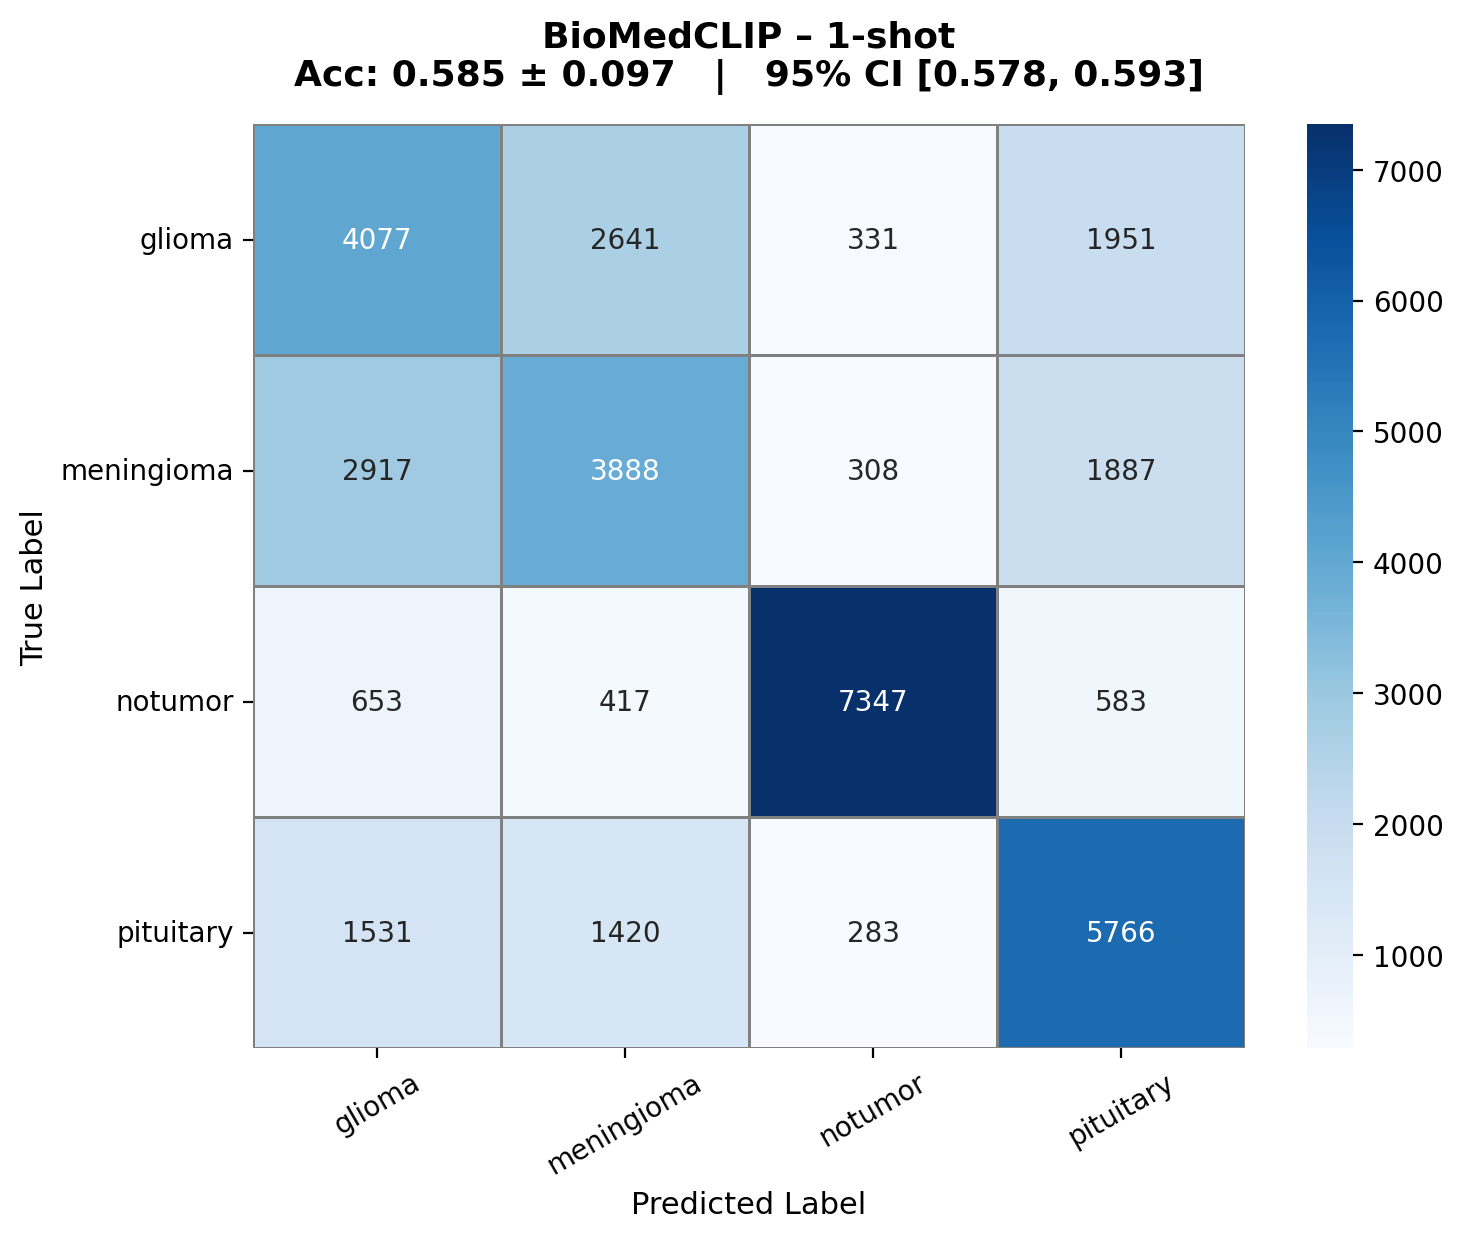

  ✓ Saved and displayed: /kaggle/working/cm_BioMedCLIP_1shot_pub.png

  1-SHOT | ResNet18  (Pure Prototypical | Leak-Free)


1-shot ResNet18: 100%|██████████| 600/600 [00:00<00:00, 648.66it/s]



  Accuracy  : 0.4463 ± 0.0921
  95% CI    : [0.4392, 0.4537]
  Macro F1  : 0.4437 | Precision: 0.4446 | Recall: 0.4463

  Per-class metrics:
    glioma       | P: 0.397 | R: 0.345 | F1: 0.369 | N: 9000
    meningioma   | P: 0.319 | R: 0.300 | F1: 0.309 | N: 9000
    notumor      | P: 0.626 | R: 0.608 | F1: 0.617 | N: 9000
    pituitary    | P: 0.436 | R: 0.533 | F1: 0.480 | N: 9000


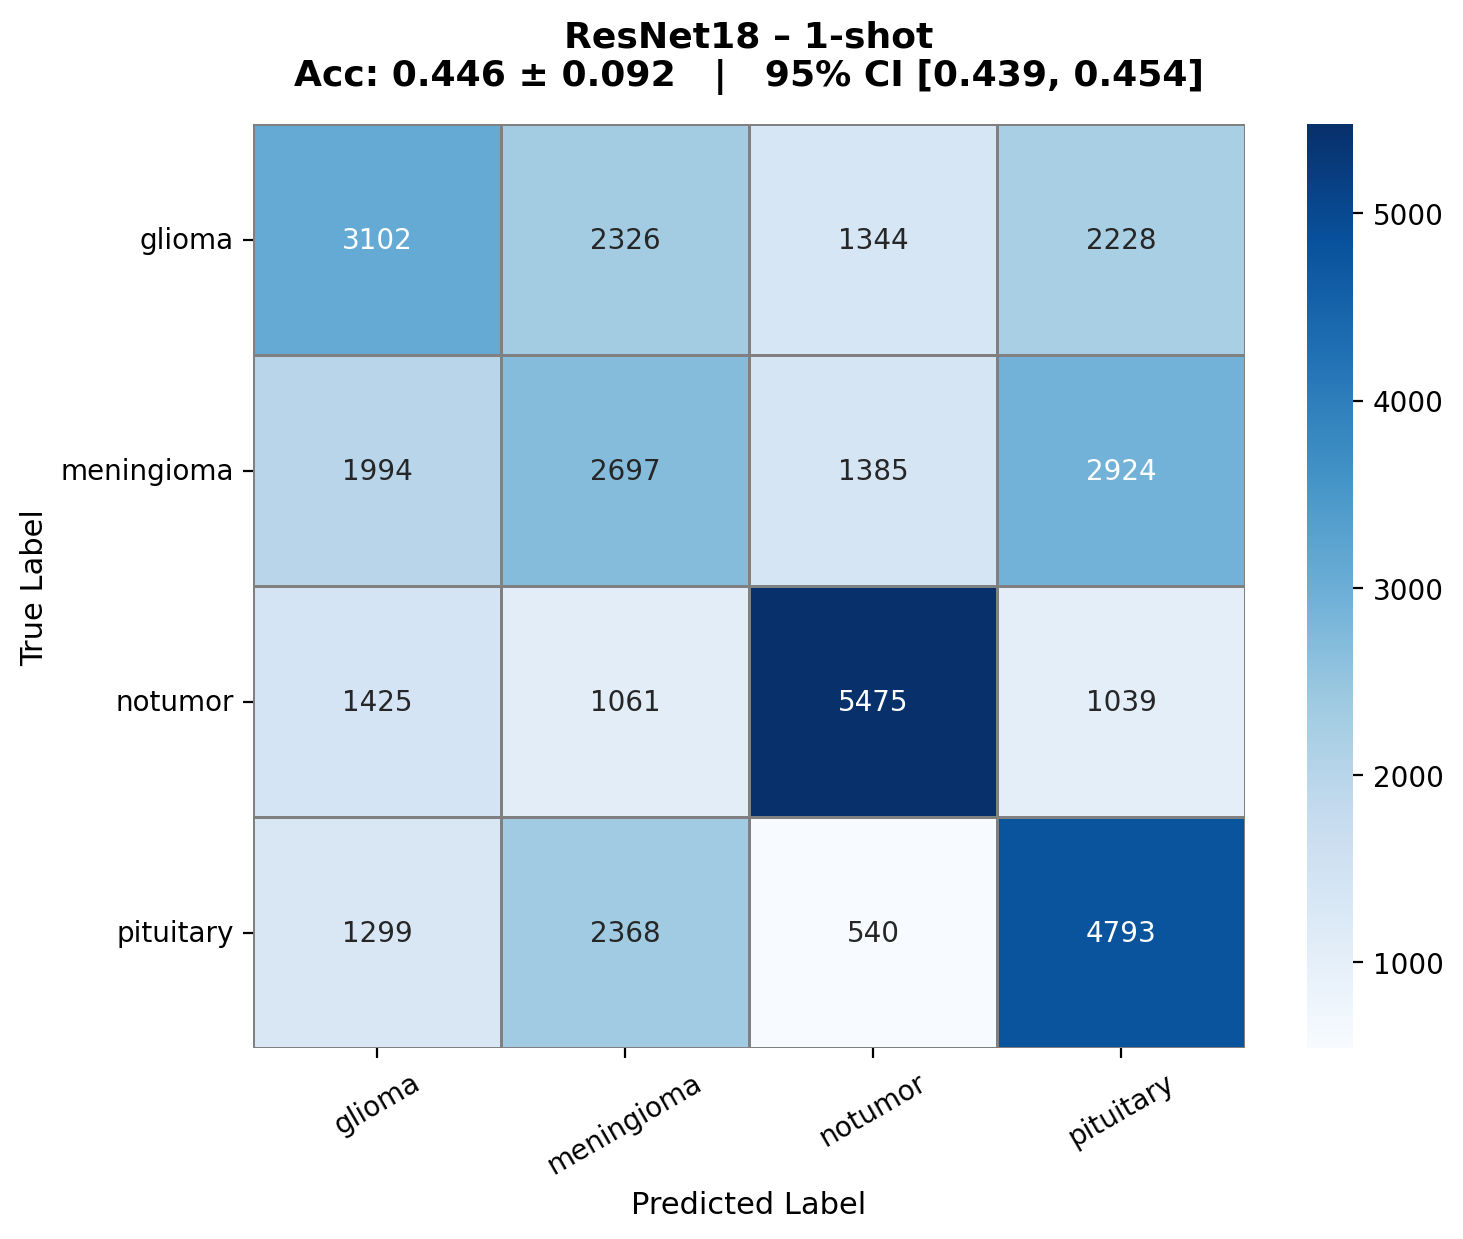

  ✓ Saved and displayed: /kaggle/working/cm_ResNet18_1shot_pub.png

  1-SHOT | EfficientNet-B0  (Pure Prototypical | Leak-Free)


1-shot EfficientNet-B0: 100%|██████████| 600/600 [00:01<00:00, 591.92it/s]



  Accuracy  : 0.4918 ± 0.0955
  95% CI    : [0.4847, 0.4997]
  Macro F1  : 0.4855 | Precision: 0.4854 | Recall: 0.4918

  Per-class metrics:
    glioma       | P: 0.417 | R: 0.349 | F1: 0.380 | N: 9000
    meningioma   | P: 0.333 | R: 0.291 | F1: 0.310 | N: 9000
    notumor      | P: 0.729 | R: 0.733 | F1: 0.731 | N: 9000
    pituitary    | P: 0.463 | R: 0.594 | F1: 0.521 | N: 9000


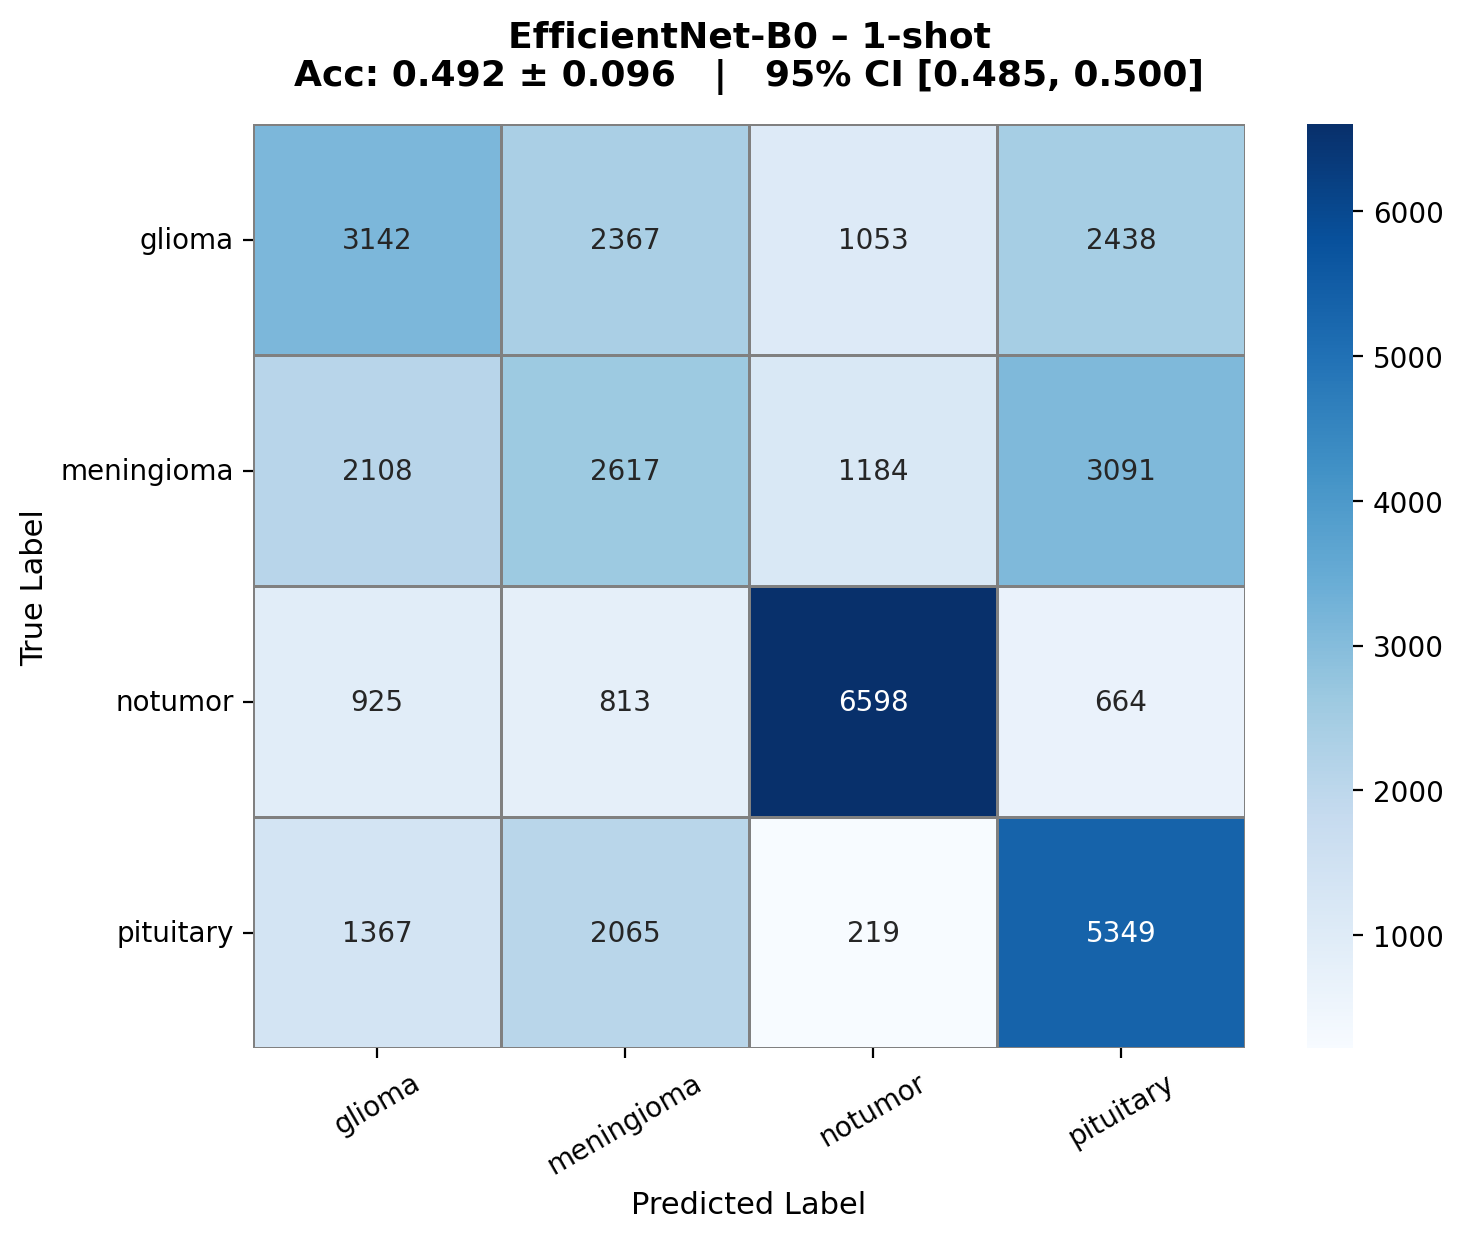

  ✓ Saved and displayed: /kaggle/working/cm_EfficientNet-B0_1shot_pub.png

  5-SHOT | BioMedCLIP  (Pure Prototypical | Leak-Free)


5-shot BioMedCLIP: 100%|██████████| 600/600 [00:00<00:00, 628.95it/s]



  Accuracy  : 0.7148 ± 0.0611
  95% CI    : [0.7097, 0.7195]
  Macro F1  : 0.7073 | Precision: 0.7127 | Recall: 0.7148

  Per-class metrics:
    glioma       | P: 0.602 | R: 0.539 | F1: 0.569 | N: 9000
    meningioma   | P: 0.622 | R: 0.493 | F1: 0.550 | N: 9000
    notumor      | P: 0.961 | R: 0.935 | F1: 0.948 | N: 9000
    pituitary    | P: 0.666 | R: 0.893 | F1: 0.763 | N: 9000


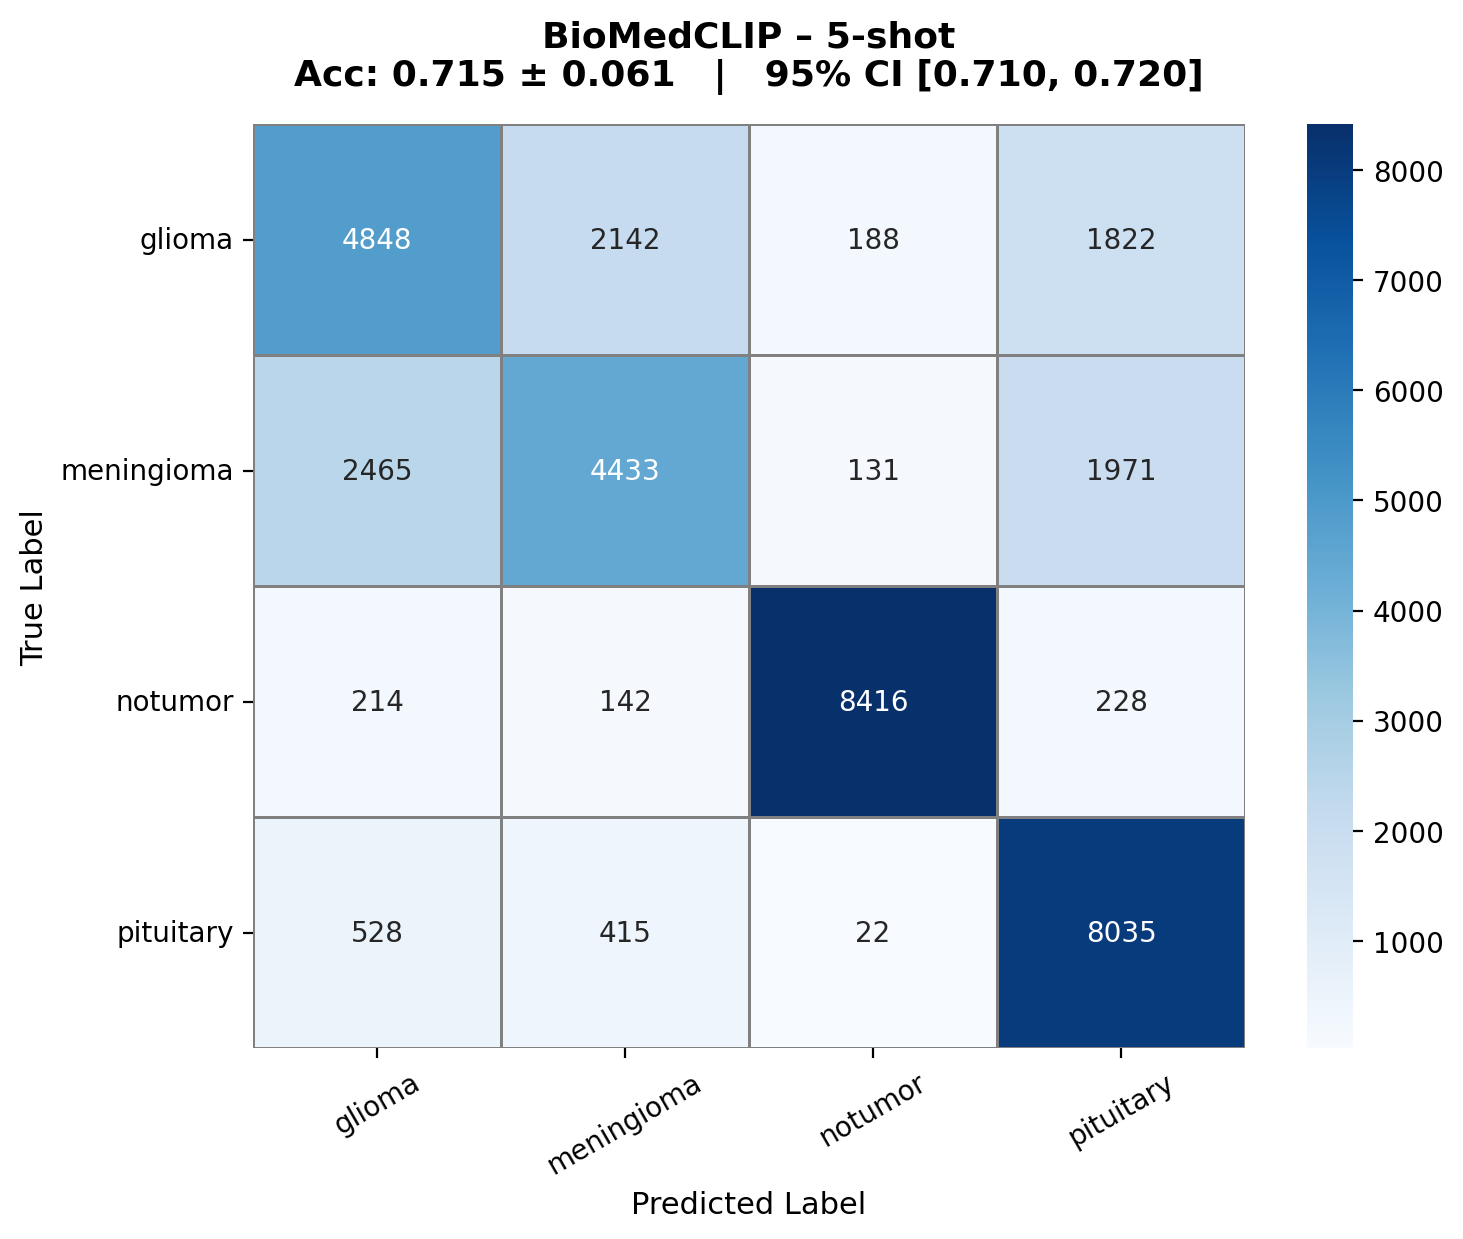

  ✓ Saved and displayed: /kaggle/working/cm_BioMedCLIP_5shot_pub.png

  5-SHOT | ResNet18  (Pure Prototypical | Leak-Free)


5-shot ResNet18: 100%|██████████| 600/600 [00:00<00:00, 619.05it/s]



  Accuracy  : 0.5935 ± 0.0665
  95% CI    : [0.5882, 0.5991]
  Macro F1  : 0.5688 | Precision: 0.5840 | Recall: 0.5935

  Per-class metrics:
    glioma       | P: 0.653 | R: 0.430 | F1: 0.518 | N: 9000
    meningioma   | P: 0.435 | R: 0.263 | F1: 0.328 | N: 9000
    notumor      | P: 0.719 | R: 0.885 | F1: 0.793 | N: 9000
    pituitary    | P: 0.529 | R: 0.797 | F1: 0.636 | N: 9000


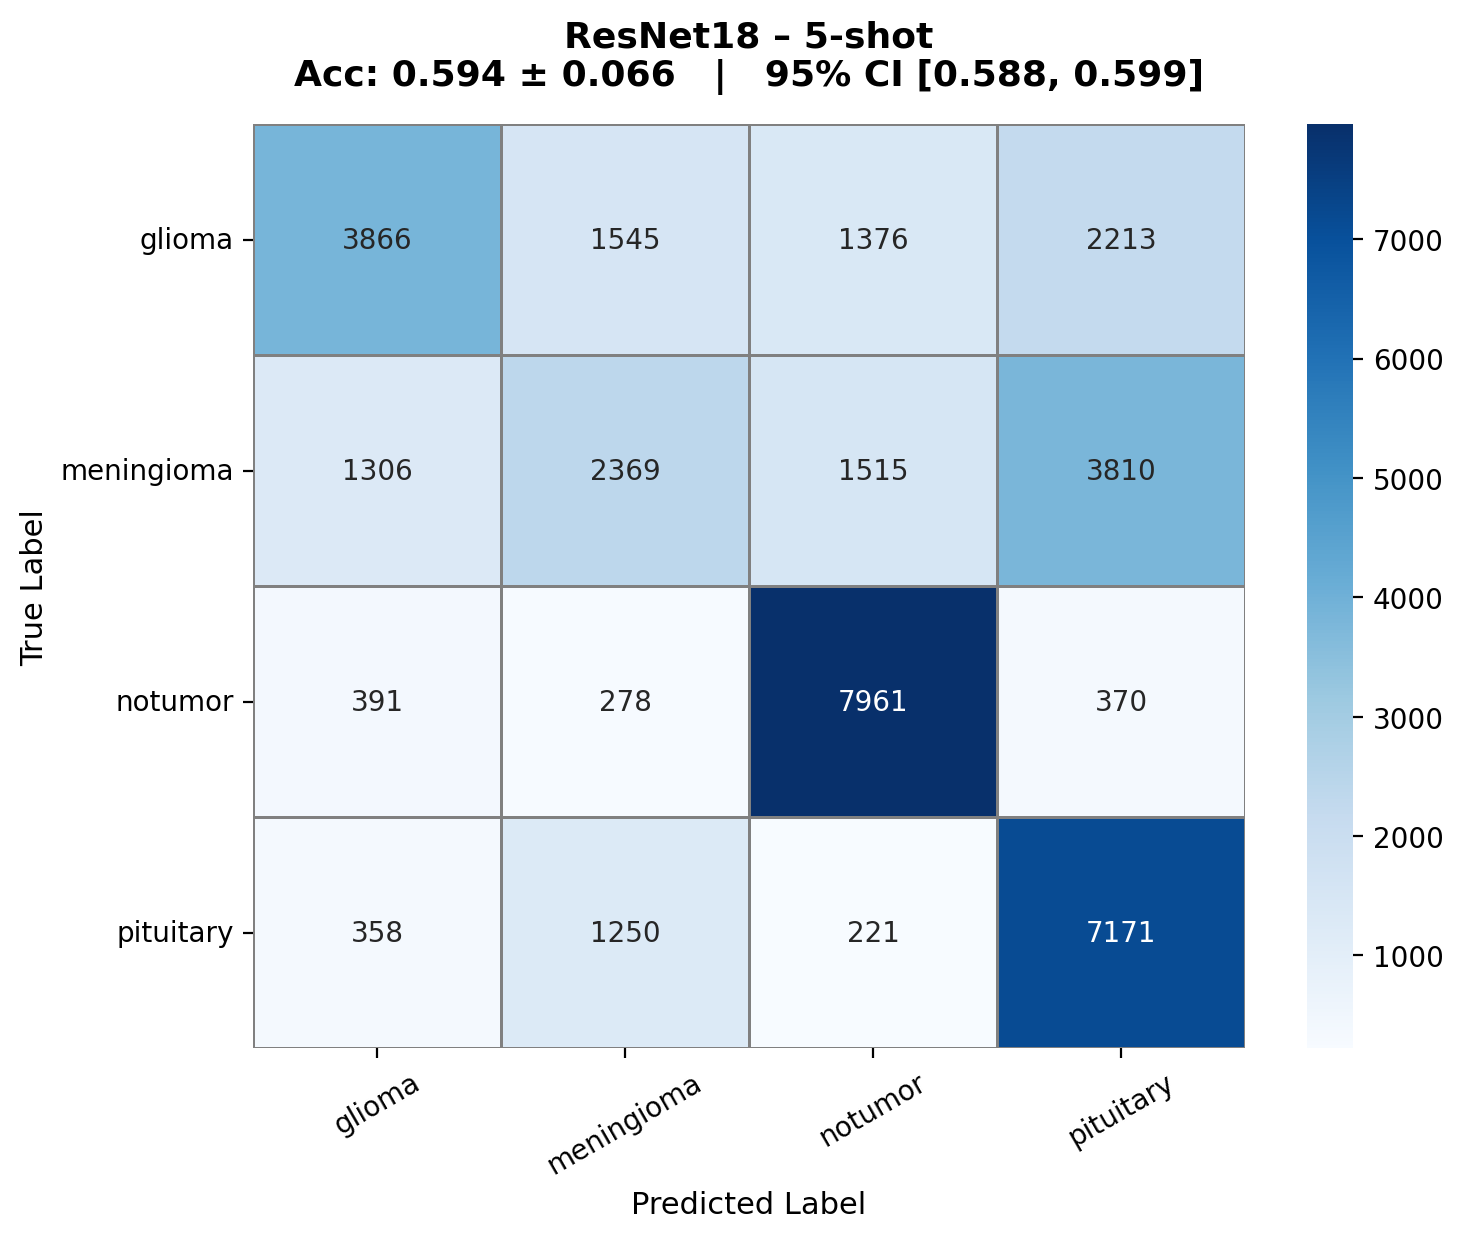

  ✓ Saved and displayed: /kaggle/working/cm_ResNet18_5shot_pub.png

  5-SHOT | EfficientNet-B0  (Pure Prototypical | Leak-Free)


5-shot EfficientNet-B0: 100%|██████████| 600/600 [00:01<00:00, 566.71it/s]



  Accuracy  : 0.6084 ± 0.0599
  95% CI    : [0.6035, 0.6129]
  Macro F1  : 0.5744 | Precision: 0.5941 | Recall: 0.6084

  Per-class metrics:
    glioma       | P: 0.614 | R: 0.397 | F1: 0.482 | N: 9000
    meningioma   | P: 0.439 | R: 0.226 | F1: 0.298 | N: 9000
    notumor      | P: 0.796 | R: 0.931 | F1: 0.858 | N: 9000
    pituitary    | P: 0.527 | R: 0.880 | F1: 0.659 | N: 9000


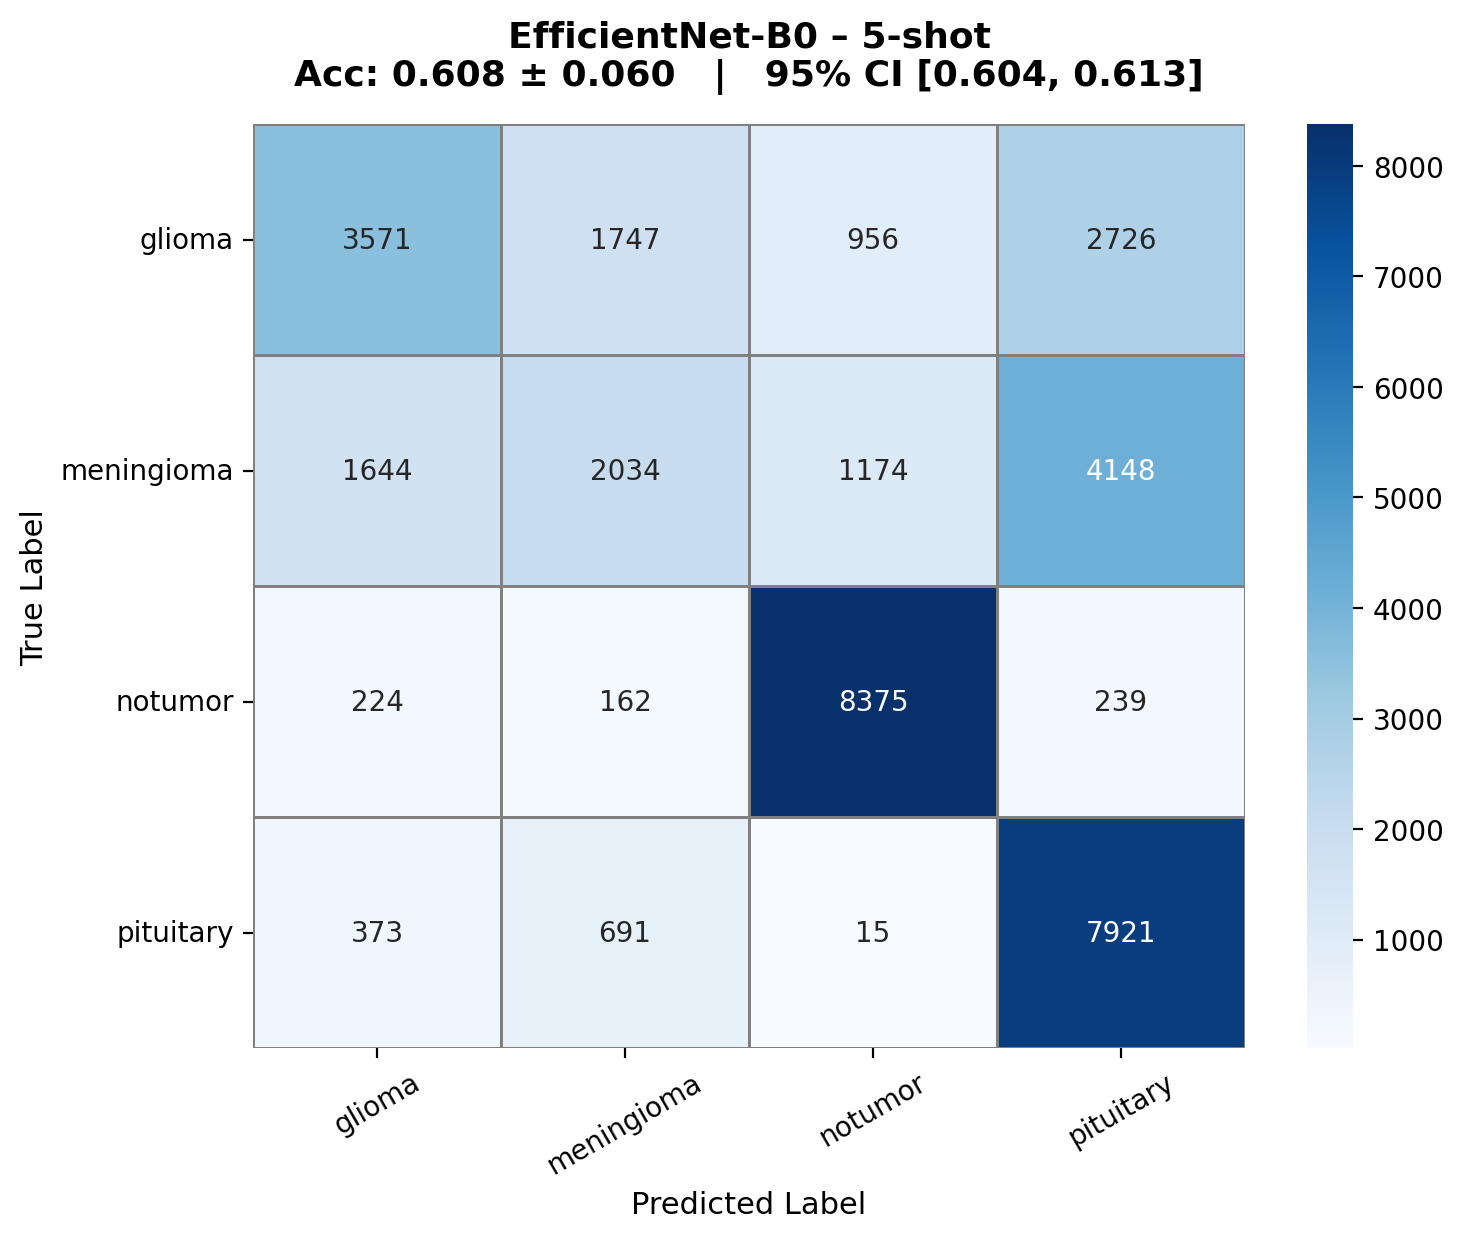

  ✓ Saved and displayed: /kaggle/working/cm_EfficientNet-B0_5shot_pub.png

  10-SHOT | BioMedCLIP  (Pure Prototypical | Leak-Free)


10-shot BioMedCLIP: 100%|██████████| 600/600 [00:00<00:00, 616.20it/s]



  Accuracy  : 0.7408 ± 0.0524
  95% CI    : [0.7368, 0.7449]
  Macro F1  : 0.7319 | Precision: 0.7395 | Recall: 0.7408

  Per-class metrics:
    glioma       | P: 0.658 | R: 0.556 | F1: 0.603 | N: 9000
    meningioma   | P: 0.655 | R: 0.518 | F1: 0.579 | N: 9000
    notumor      | P: 0.963 | R: 0.948 | F1: 0.955 | N: 9000
    pituitary    | P: 0.682 | R: 0.941 | F1: 0.791 | N: 9000


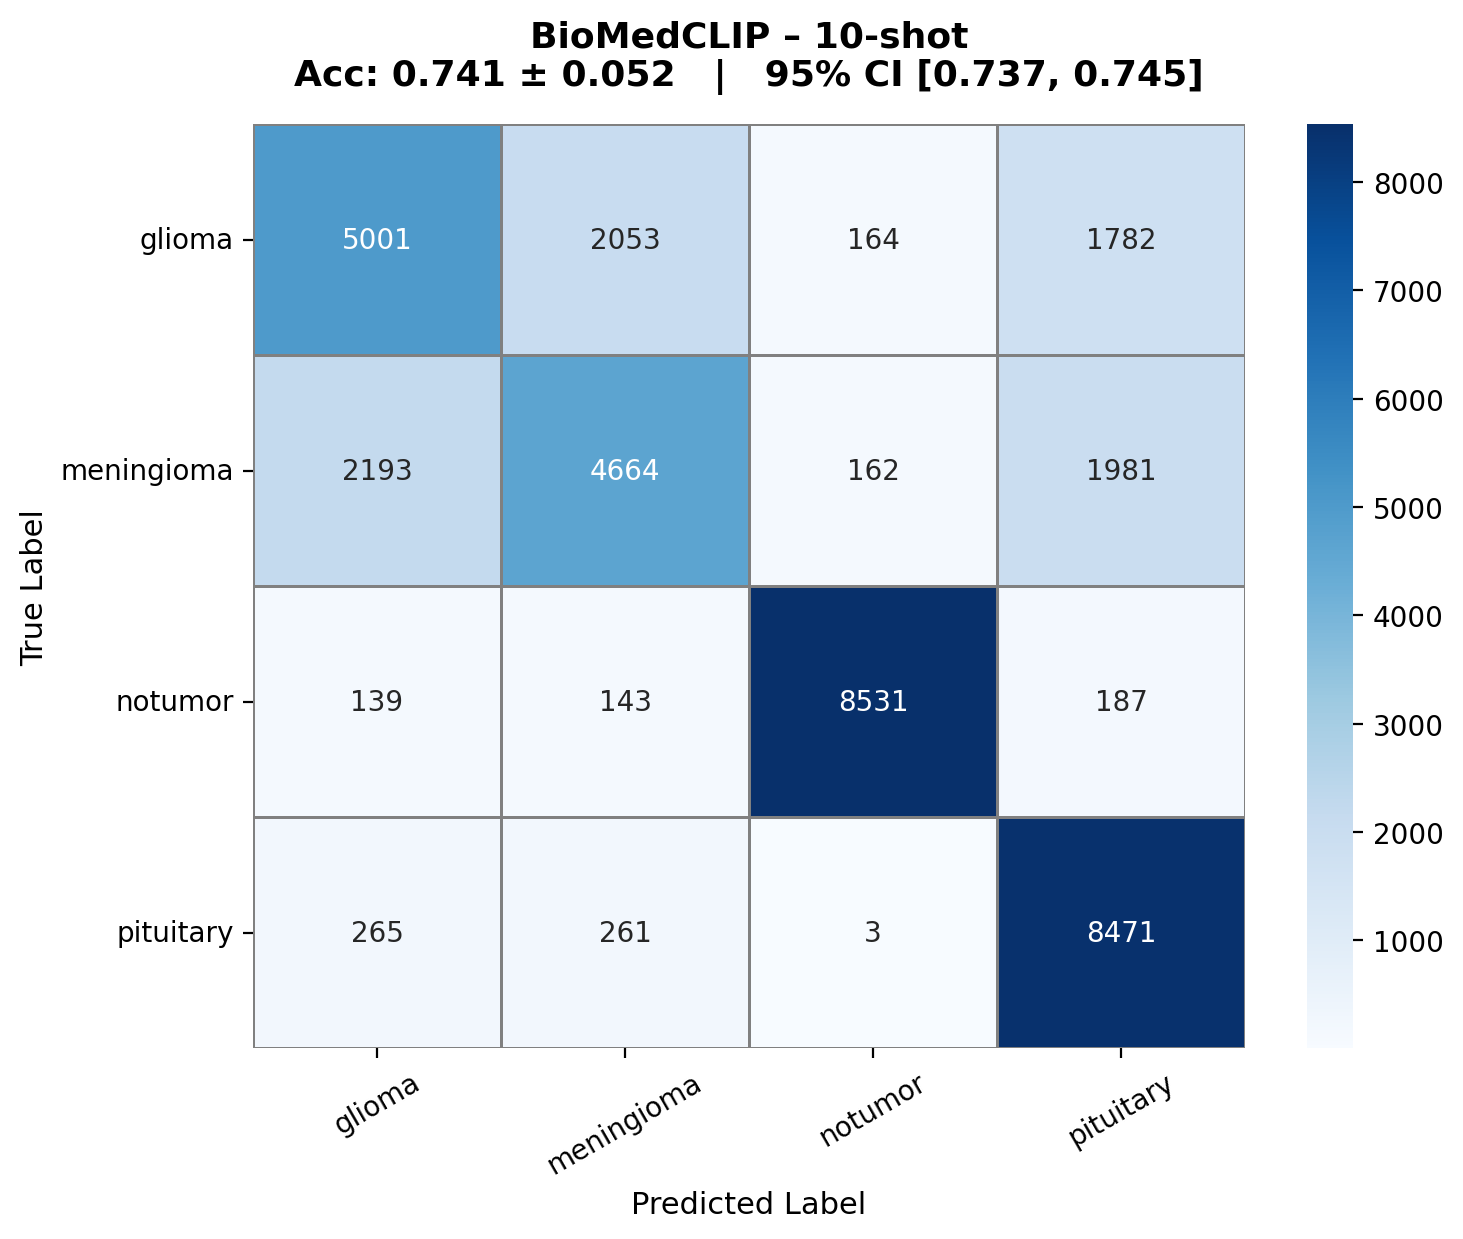

  ✓ Saved and displayed: /kaggle/working/cm_BioMedCLIP_10shot_pub.png

  10-SHOT | ResNet18  (Pure Prototypical | Leak-Free)


10-shot ResNet18: 100%|██████████| 600/600 [00:00<00:00, 611.53it/s]



  Accuracy  : 0.6257 ± 0.0542
  95% CI    : [0.6215, 0.6300]
  Macro F1  : 0.5908 | Precision: 0.6216 | Recall: 0.6257

  Per-class metrics:
    glioma       | P: 0.727 | R: 0.457 | F1: 0.561 | N: 9000
    meningioma   | P: 0.491 | R: 0.228 | F1: 0.311 | N: 9000
    notumor      | P: 0.721 | R: 0.938 | F1: 0.816 | N: 9000
    pituitary    | P: 0.548 | R: 0.879 | F1: 0.675 | N: 9000


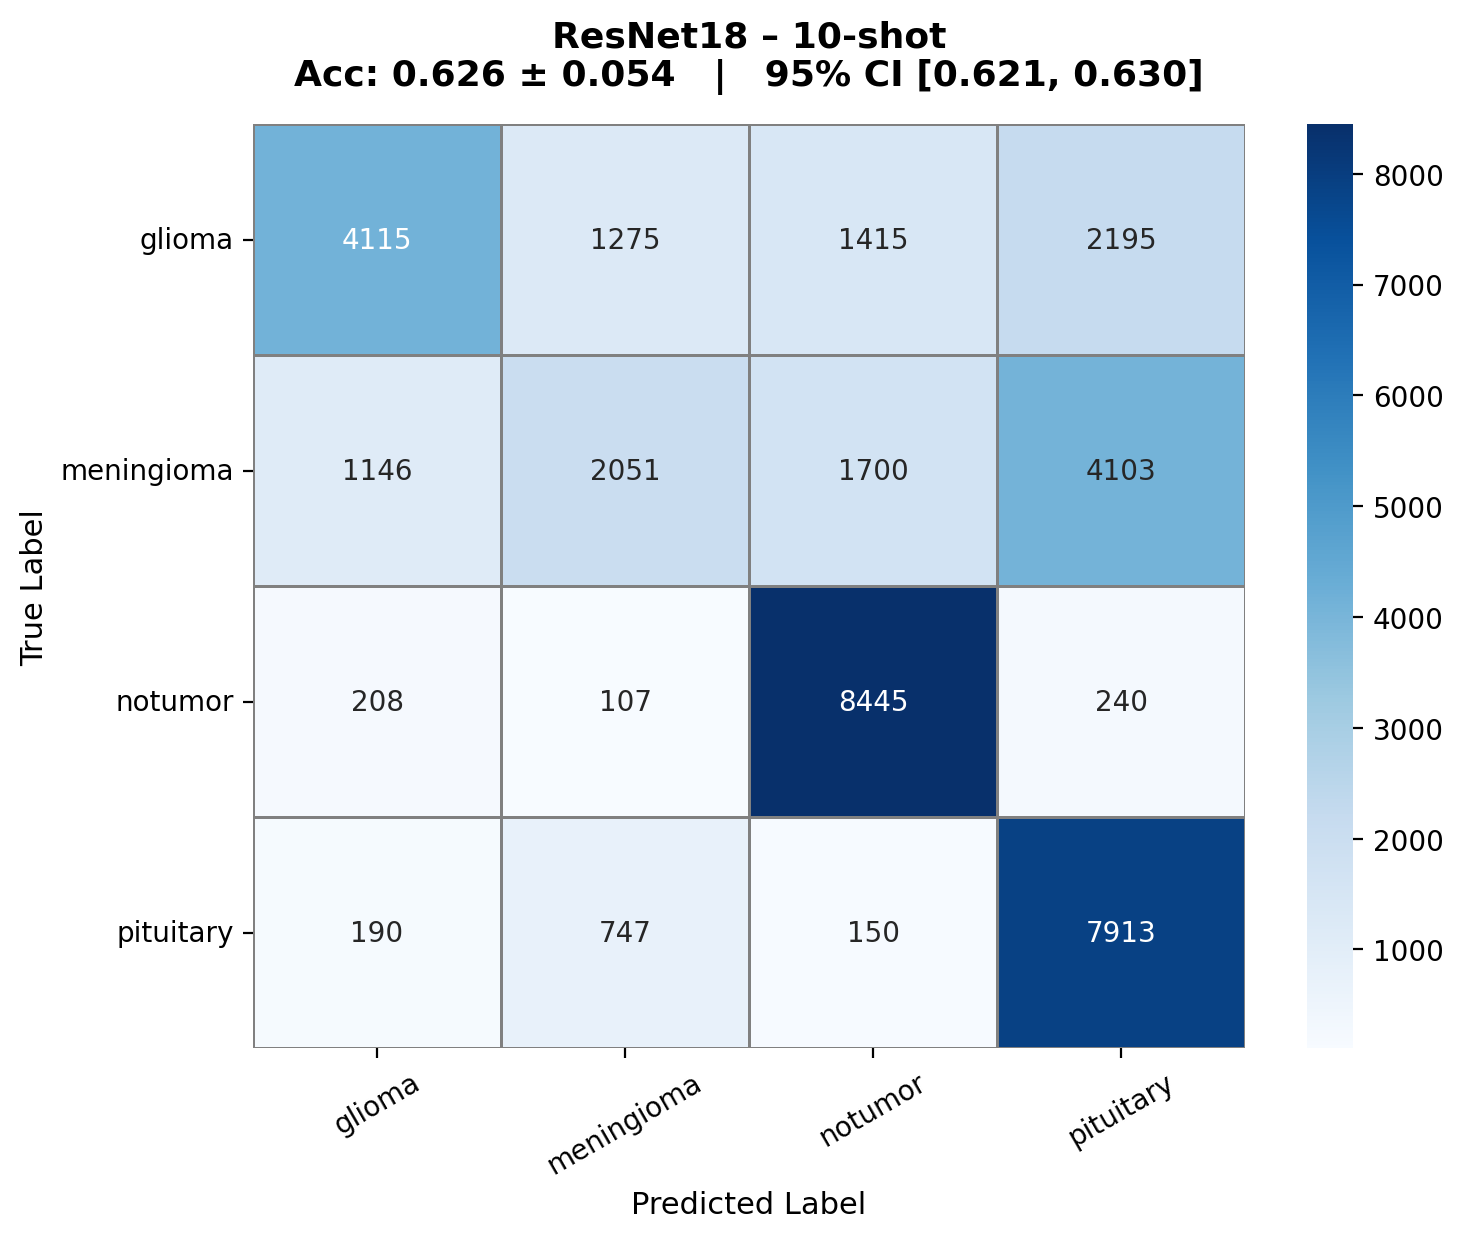

  ✓ Saved and displayed: /kaggle/working/cm_ResNet18_10shot_pub.png

  10-SHOT | EfficientNet-B0  (Pure Prototypical | Leak-Free)


10-shot EfficientNet-B0: 100%|██████████| 600/600 [00:01<00:00, 551.88it/s]



  Accuracy  : 0.6229 ± 0.0555
  95% CI    : [0.6184, 0.6272]
  Macro F1  : 0.5801 | Precision: 0.6225 | Recall: 0.6229

  Per-class metrics:
    glioma       | P: 0.685 | R: 0.404 | F1: 0.508 | N: 9000
    meningioma   | P: 0.485 | R: 0.191 | F1: 0.274 | N: 9000
    notumor      | P: 0.802 | R: 0.945 | F1: 0.868 | N: 9000
    pituitary    | P: 0.518 | R: 0.952 | F1: 0.671 | N: 9000


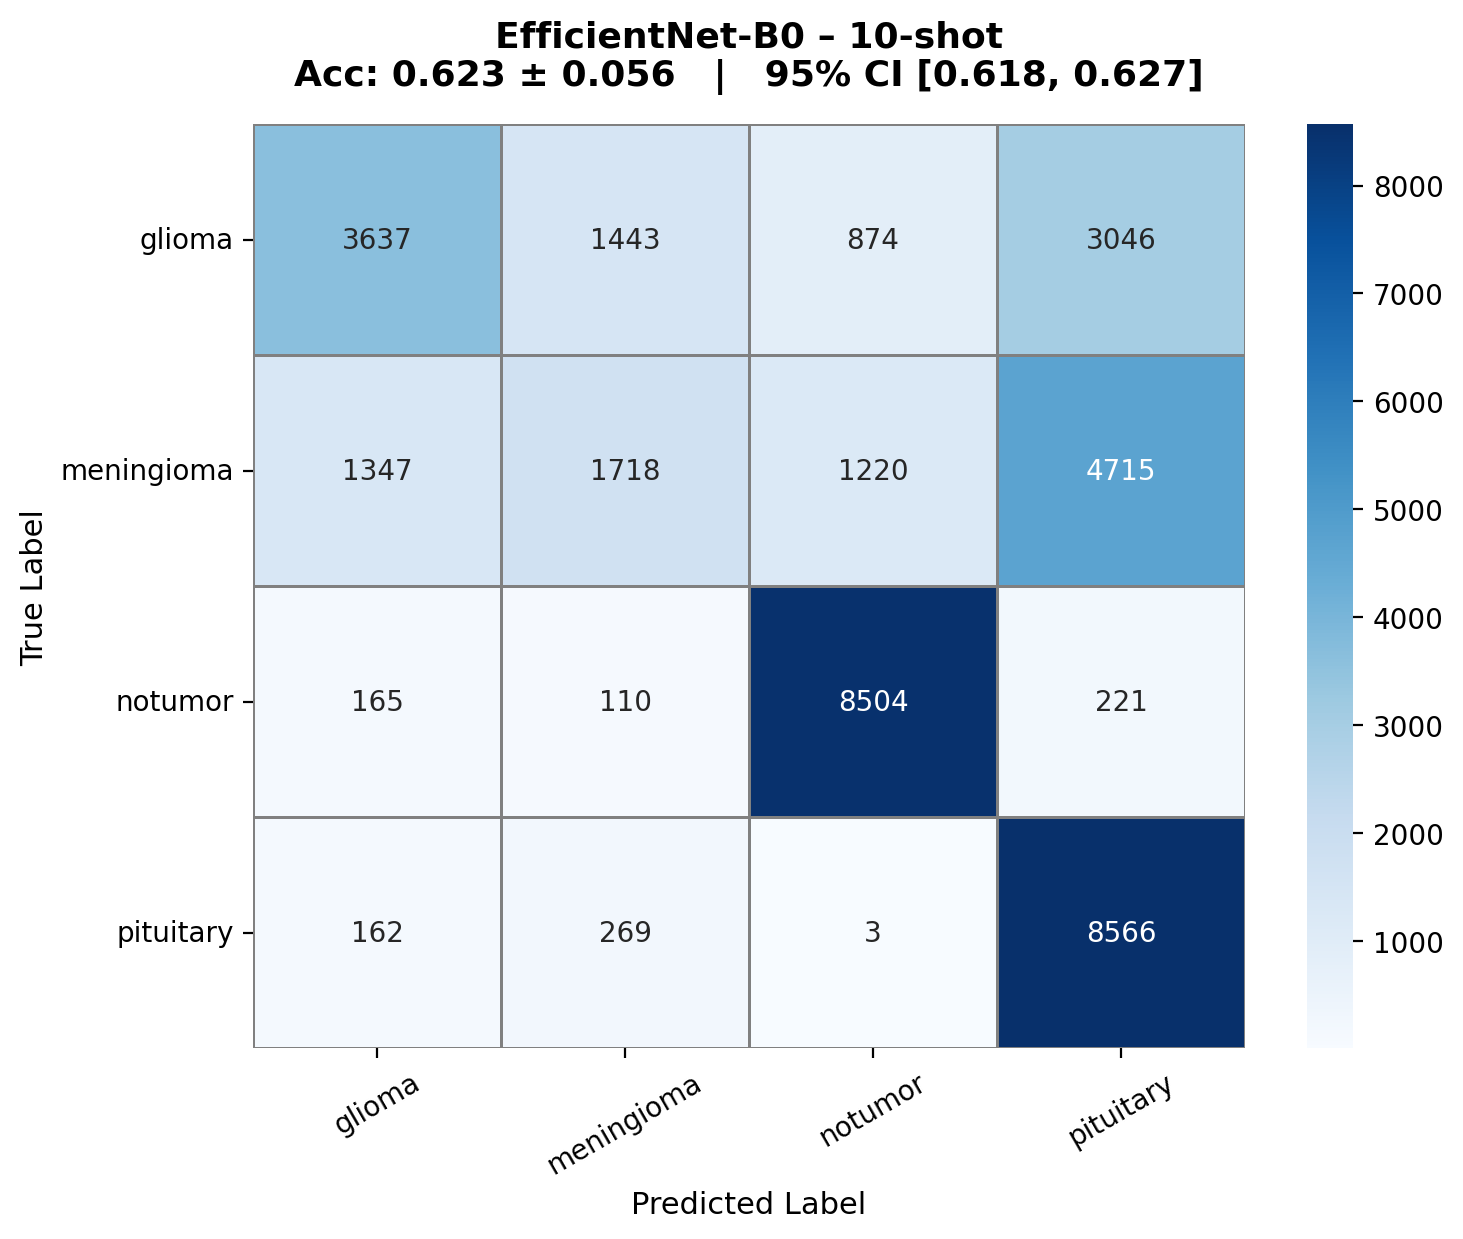

  ✓ Saved and displayed: /kaggle/working/cm_EfficientNet-B0_10shot_pub.png

##########################################################################################
 STATISTICAL SIGNIFICANCE (McNemar's Test)
##########################################################################################

 FINAL RESULTS SUMMARY


In [23]:
# ========================= RUN ALL EXPERIMENTS =========================
results = {}
print(f"\n{'#'*90}")
print("FEW-SHOT EXPERIMENTS (600 Episodes)")
print(f"{'#'*90}\n")

for k in SHOTS:
    for name in model_configs:
        key = f"{name}_{k}shot"
        results[key] = run_fewshot(k_shot=k, name=name)

# McNemar tests
print(f"\n{'#'*90}")
print(" STATISTICAL SIGNIFICANCE (McNemar's Test)")
print(f"{'#'*90}")
for k in SHOTS:
    model_names = list(model_configs.keys())
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            ma, mb = model_names[i], model_names[j]
            ra = results[f"{ma}_{k}shot"]
            rb = results[f"{mb}_{k}shot"]
           

# Summary table
print(f"\n{'='*90}")
print(f" FINAL RESULTS SUMMARY")
print(f"{'='*90}")



Generating summary visualizations...


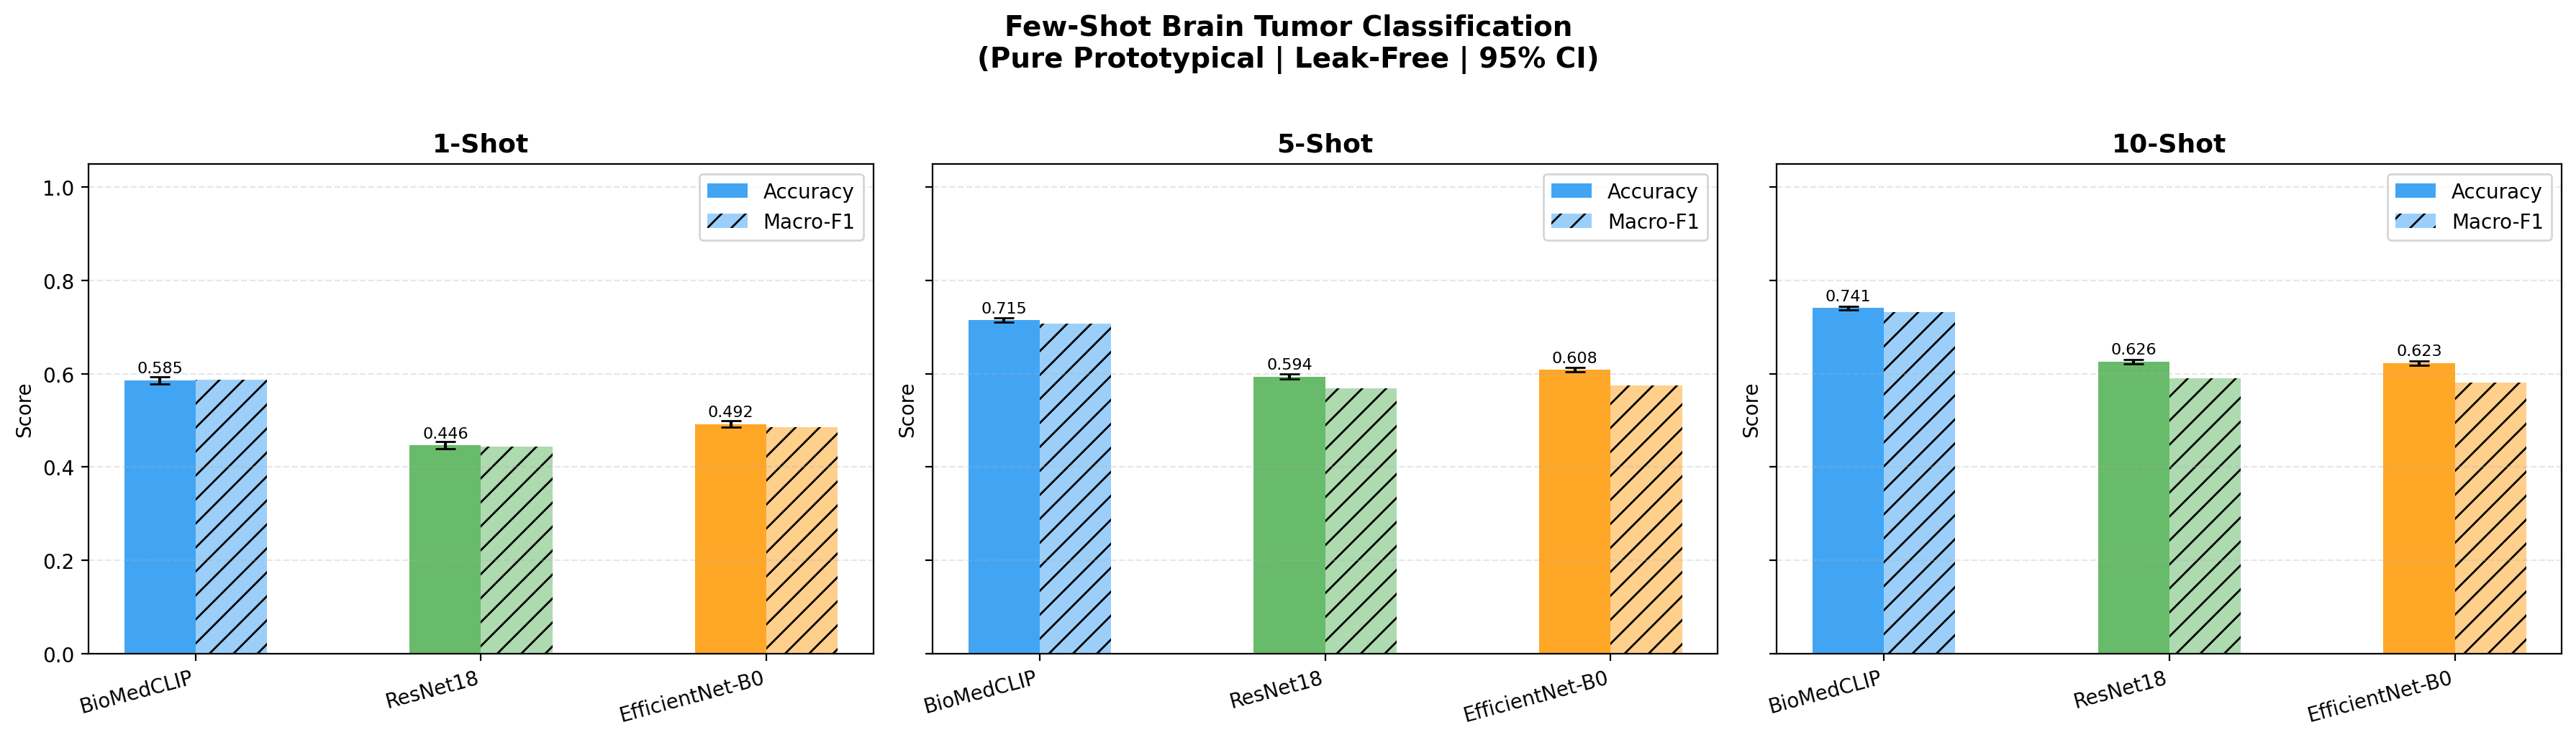

  ✓ Saved and displayed: /kaggle/working/summary_accuracy_f1.png


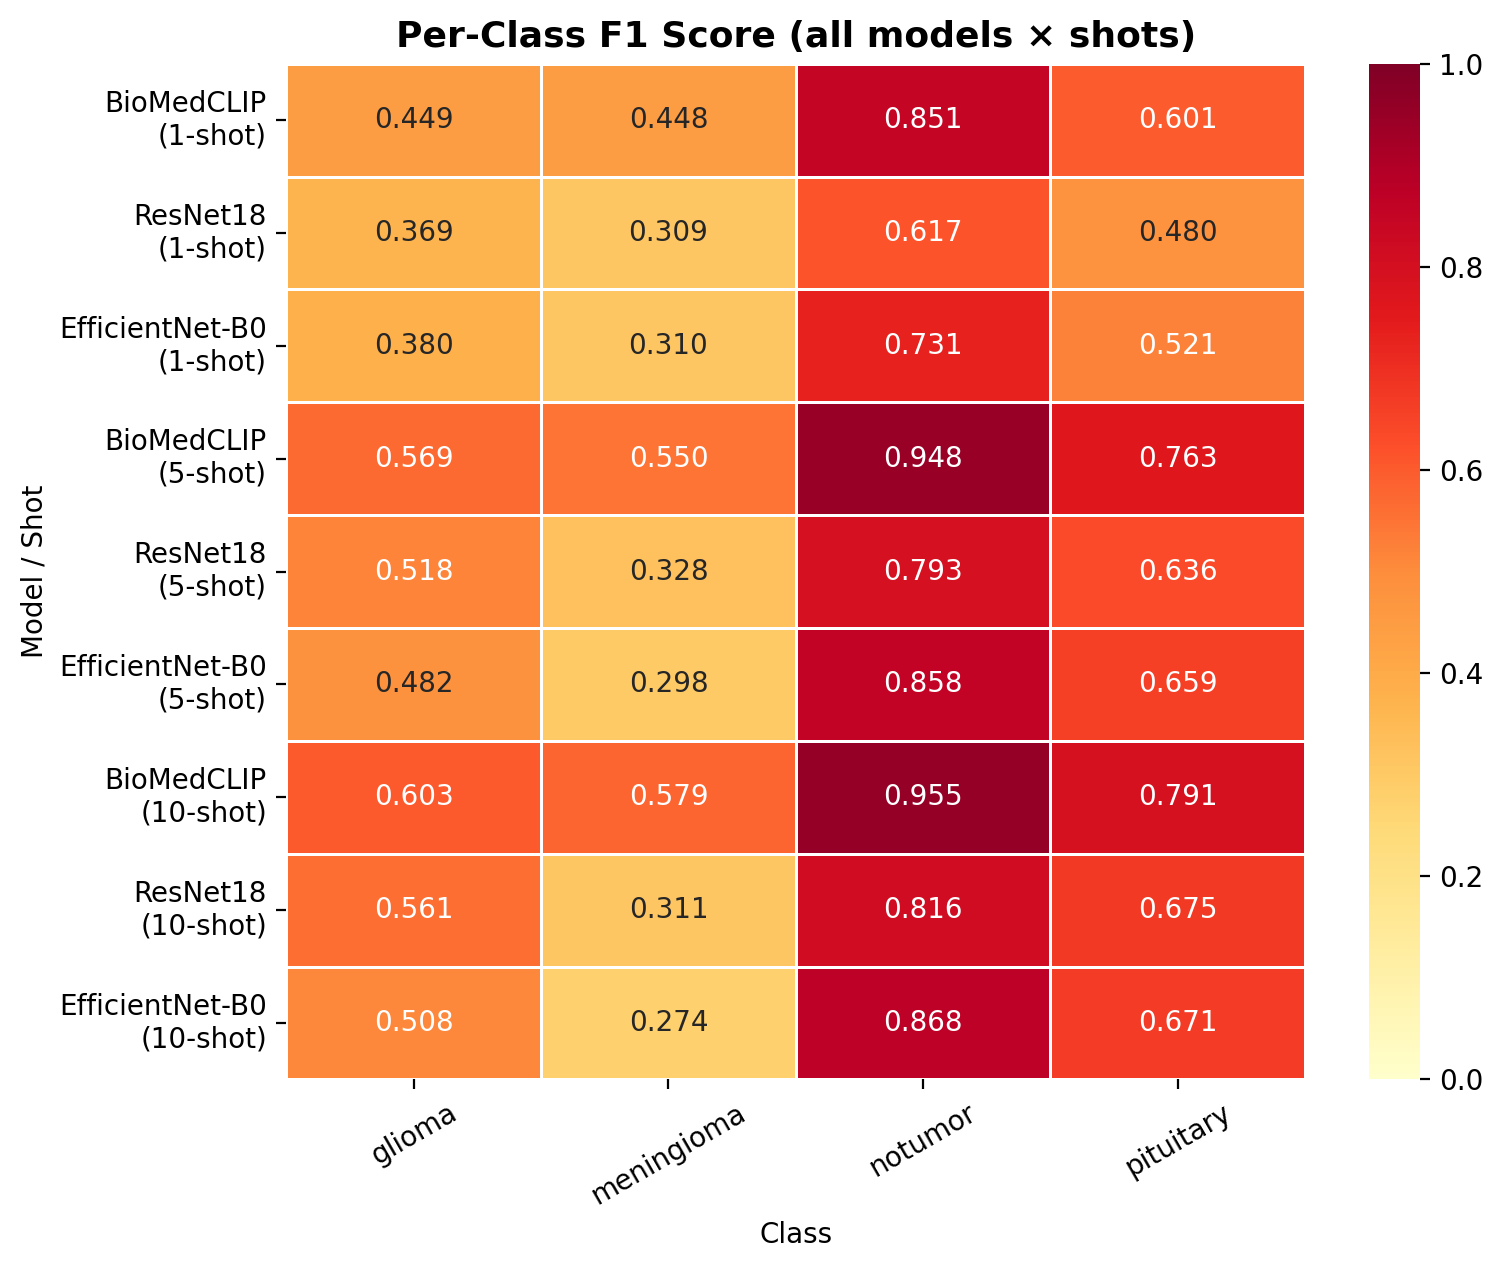

  ✓ Saved and displayed: /kaggle/working/perclass_f1_heatmap.png


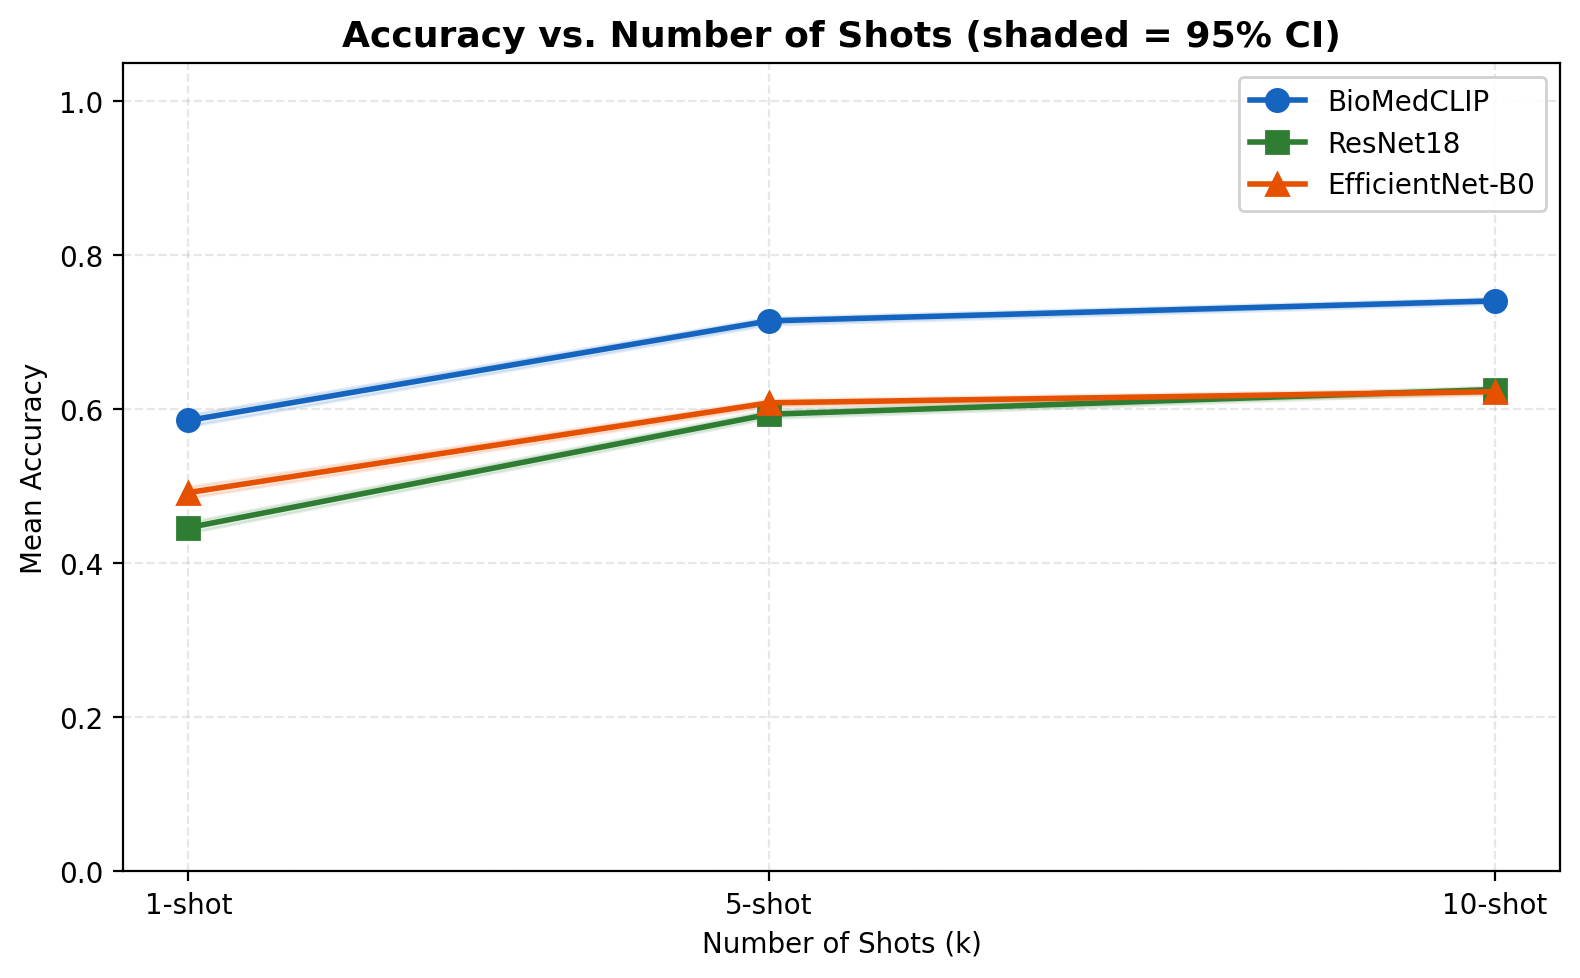

  ✓ Saved and displayed: /kaggle/working/shot_progression.png


In [24]:

# ========================= FINAL VISUALIZATIONS =========================
print("\nGenerating summary visualizations...")
plot_summary_chart(results, SHOTS, list(model_configs.keys()))
plot_perclass_heatmap(results, SHOTS, list(model_configs.keys()))
plot_shot_progression(results, SHOTS, list(model_configs.keys()))


